   TransactionAmount  TransactionTime  AccountAge  FailedAttempts  \
0                870               12          51               6   
1               3782                3        3209               9   
2               3102               18        1182               9   
3                476                1          56               5   
4               4436                8         744               3   

   DistanceFromHome  DeviceChange  InternationalTransaction  Fraud  
0               125             0                         1      0  
1               425             1                         1      1  
2               373             1                         0      0  
3               347             1                         0      0  
4                82             1                         0      0  
Accuracy: 0.956
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1772
           1       0.94      0.65      0.77   

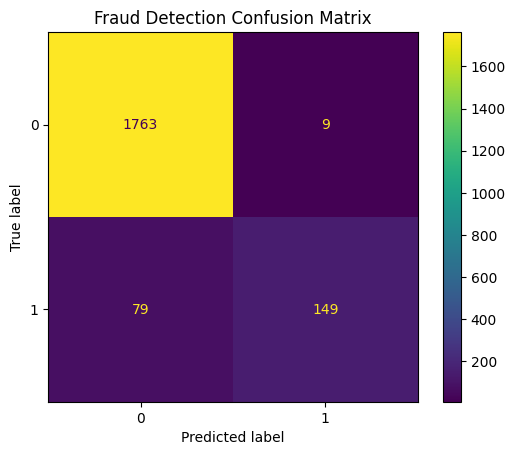

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 10000

data = pd.DataFrame({
    "TransactionAmount": np.random.randint(10, 5000, n),
    "TransactionTime": np.random.randint(0, 24, n),
    "AccountAge": np.random.randint(1, 3650, n),
    "FailedAttempts": np.random.randint(0, 10, n),
    "DistanceFromHome": np.random.randint(1, 500, n),
    "DeviceChange": np.random.choice([0,1], n),
    "InternationalTransaction": np.random.choice([0,1], n)
})

#fraud logic
data["Fraud"] = (
    (data["TransactionAmount"] > 3000) &
    (data["FailedAttempts"] > 5) &
    (data["InternationalTransaction"] == 1)
).astype(int)

#tambah noise biar realistis
noise = np.random.choice([0,1], size=n, p=[0.95, 0.05])
data["Fraud"] = np.abs(data["Fraud"] - noise)

print(data.head())

from sklearn.model_selection import train_test_split

X = data.drop("Fraud", axis=1)
y = data["Fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.3).astype(int)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Fraud Detection Confusion Matrix")
plt.show()
